# Reproducing Fig.1 in Capel+2020

In [13]:
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# --- Fig. 1 reproduction (family of models) -----------------------------------
import numpy as np
import matplotlib.pyplot as plt

from icecube_population_project.nu_pop_core import (
    CosmologyGrid, SpectrumParams, PopulationParams,
    fz_sfr_md14, fz_flat, fz_negative, fz_powerlaw,
    fig1_Pz_and_cdf
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

# 1) Cosmology + redshift grid
cosmo = CosmologyGrid(zmax=6.0, nz=4000)
z = cosmo.z

# 2) Spectrum (Eqs. 1–2). For Fig. 1, only gamma matters after normalization.
#    Keep energies consistent; they won't affect P(z) once we normalize Eq. (9).
spec = SpectrumParams(gamma=2.0, Emin=1e5, Emax=1e8, L=1e42)  # units arbitrary but consistent

# 3) Define a family of evolution models f(z) (Eq. 4)
models = []

# Reference overlays (Source density evolution models)
models.append(("SFR (MD14)", fz_sfr_md14(z)))
models.append(("Flat", fz_flat(z)))
models.append(("Negative", fz_negative(z)))

# Build P(z) and C(z) 
PC = {}
for label, fz in models:  #
    pop = PopulationParams(n0=1e-6, fz_fn=lambda zz, arr=fz: np.interp(np.asarray(zz,float), z, arr))
    P, C = fig1_Pz_and_cdf(z, cosmo, spec, pop)   # calls the robust integrand now
    assert np.all(np.isfinite(P)), f"{label}: non-finite P(z)"
    assert P.max() > 0, f"{label}: zero P(z)"
    assert np.isclose(np.trapz(P, z), 1.0, rtol=5e-4, atol=5e-4)
    PC[label] = (P, C)



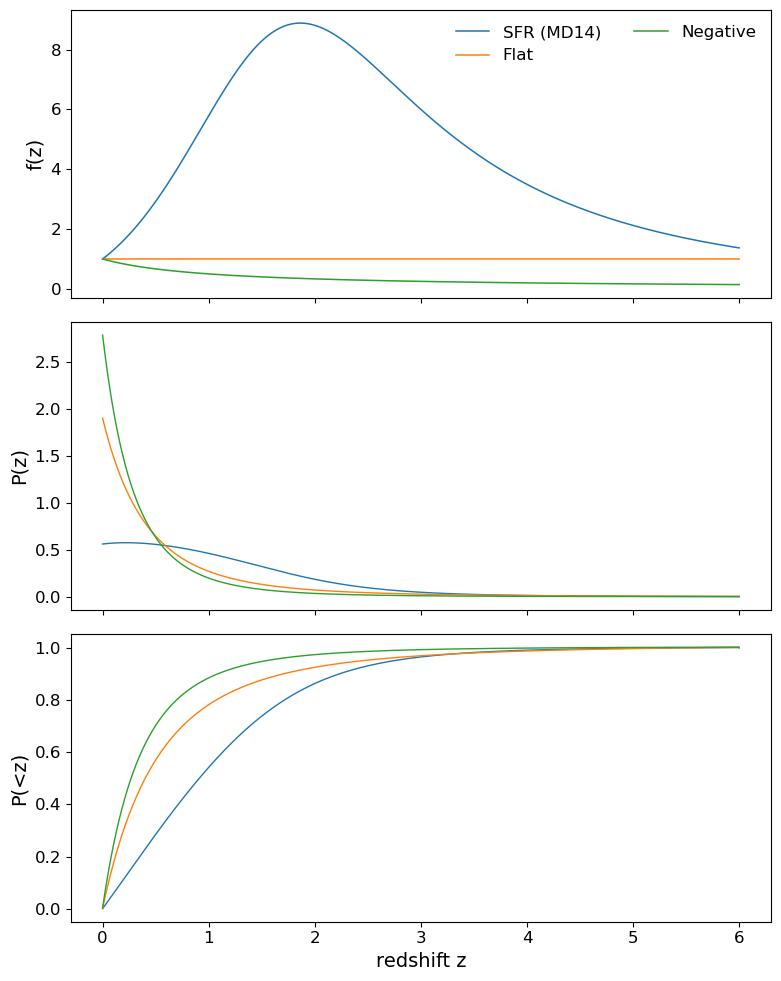

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- set global font sizes ---
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

# plot
fig, ax = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# f(z) - source density evolution models in Eq.(4)
for label, fz in models:
    ax[0].plot(z, fz/fz[0], lw=1.1)
ax[0].set_ylabel("f(z)")
ax[0].legend([m[0] for m in models[:4]], ncol=2, frameon=False, loc="upper right")

# P(z)
for label, (P, C) in PC.items():
    ax[1].plot(z, P, lw=1.0)
ax[1].set_ylabel("P(z)")

# P(<z)
for label, (P, C) in PC.items():
    ax[2].plot(z, C, lw=1.0)
ax[2].set_ylabel("P(<z)")
ax[2].set_xlabel("redshift z")

plt.tight_layout()
plt.show()



## Sanity check for this first code

In [19]:
def summarize(label, z, P, C):
    area = np.trapz(P, z)
    z_med = np.interp(0.5, C, z)
    z_90  = np.interp(0.9, C, z)
    z_peak = z[np.argmax(P)]
    print(f"{label:12s}  ∫Pdz={area:.6f}  z_peak={z_peak:.3f}  z50={z_med:.3f}  z90={z_90:.3f}")

for label, (P, C) in PC.items():
    summarize(label, z, P, C)

#OM: Results look OK!


SFR (MD14)    ∫Pdz=1.000000  z_peak=0.221  z50=0.911  z90=2.233
Flat          ∫Pdz=1.000000  z_peak=0.000  z50=0.401  z90=1.706
Negative      ∫Pdz=1.000000  z_peak=0.000  z50=0.268  z90=1.086
